# Notes on this notebook
    This notebook is to work on solving stokes on a large, coarse mesh and then use that as the boundary condition for fine meshes around the boreholes.

# 0. Import packages

In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import firedrake
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask

%matplotlib widget

# 0. Not important stuff (pre season planning for AH 25/26)

In [2]:
new_GPS_stakes = pd.read_csv('../stuff_forAH2526/new_GPS_stakes_AH2526.csv')
# axes.scatter(new_GPS_stakes['X'], new_GPS_stakes['Y'], marker='^', color='magenta', s=100, label='New GPS stakes')

# 1.0 Load the DEMs

In [3]:
# Fine DEM

src_bed_fine = rasterio.open("../Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif")
src_surf_fine = rasterio.open("../Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif")

# Course DEM

src_bed_coarse = rasterio.open("../Meshes/ThreeD_meshing/bedmachine_ian_merged_bed_large_aoi_8m_aligned_fixed.tif")
src_surf_coarse = rasterio.open("../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif")

### Load the outline of the good dem

with rasterio.open('../Meshes/good_dem_outline/ian_bed_outline_raster_full.tif') as src_good_dem:
    good_dem_filter = src_good_dem.read(2)

## 1.0.1 Resample the DEMs to desired resolution

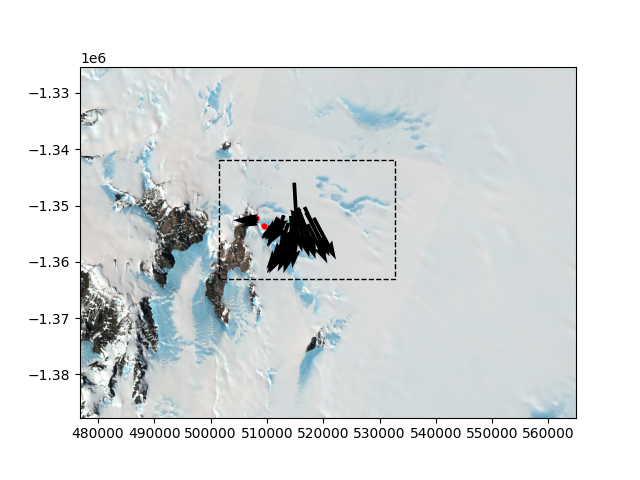

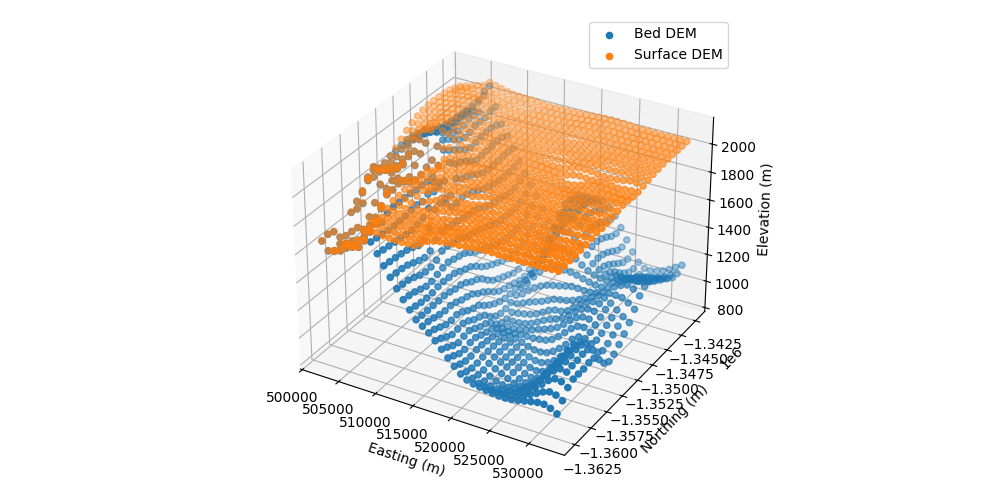

In [4]:
# Load tiff files of the DEMs

src_bed = src_bed_coarse
src_surf = src_surf_coarse

upscale_factor = 1/100


bed_DEM = src_bed.read(1,
                        out_shape=(
                            src_bed.count,
                            int(src_bed.height * upscale_factor),
                            int(src_bed.width * upscale_factor)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_bed_transform = src_bed.transform * src_bed.transform.scale(
    (src_bed.width / bed_DEM.shape[-1]),
    (src_bed.height / bed_DEM.shape[-2])
)


# src_surf = rasterio.open("../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif")

surf_DEM = src_surf.read(1,
                        out_shape=(
                            src_surf.count,
                            int(src_surf.height * upscale_factor),
                            int(src_surf.width * upscale_factor)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_surf_transform = src_surf.transform * src_surf.transform.scale(
    (src_surf.width / surf_DEM.shape[-1]),
    (src_surf.height / surf_DEM.shape[-2])
)

### Check if the bed DEMs is higher than the surface DEM (thickness is negative) ###


thickness = surf_DEM - bed_DEM
thickness[thickness > 0] = 0  # if positive, set to 0. This will mask the negative thickness values
zero_offset = copy.deepcopy(thickness)
zero_offset[zero_offset < 0 ] = -1 # this mask will lower the bed a further 1m in the areas where thickness is negative so the model doesn't crash on a zero.
bed_DEM = bed_DEM + thickness + zero_offset # add the negative values to the bed to push it lower to match the surface DEM



# surf_DEM[surf_DEM==0] = 2000 
# bed_DEM[bed_DEM==-1] = 1999
## Downsample the DEMs if desired
# downsample_factor = 20
# surf_DEM = surf_DEM[::downsample_factor, ::downsample_factor]
# bed_DEM = bed_DEM[::downsample_factor, ::downsample_factor]

height = surf_DEM.shape[0]
width = surf_DEM.shape[1]
cols, rows = np.meshgrid(np.arange(width), np.arange(height))
xs, ys = rasterio.transform.xy(src_surf_transform, rows, cols)
lons= np.array(xs)
lats = np.array(ys)

surf_elevs = surf_DEM.flatten()
bed_elevs = bed_DEM.flatten()

ax = plt.figure(figsize=[10,5]).add_subplot(projection='3d')

ax.scatter(lons, lats, bed_elevs, label="Bed DEM")
ax.scatter(lons, lats, surf_elevs, label="Surface DEM")

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_zlabel('Elevation (m)')


ax.legend()

plt.tight_layout()

# plt.savefig('DEM_coarse_3D_view.png', dpi=300, transparent=True)

### Load boreholes
borehole_locations = pd.read_csv('../Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

### Load image data

with rasterio.open('../imagery/LIMA_virtual_Mosaic_15m.tif') as src1:
    image_data = src1.read()

fig, ax = plt.subplots()
ax.scatter(transformed_x,transformed_y, marker='.',c='red', label='Boreholes')
show(image_data,ax=ax,transform=src1.transform)

width_m = src_surf_transform[0] *surf_DEM.shape[1]
height_m = src_surf_transform[4] *surf_DEM.shape[0]

ax.add_patch(plt.Rectangle((src_surf_transform[2], src_surf_transform[5]),width_m,height_m,  ls='--', ec='black',fc='None'))

### Load the GPS velocities
gps_velocities = pd.read_csv('../GPS_velocities/24-25_velocities-good.csv')

GPS_points = []
for i in gps_velocities.iloc():
    GPS_points.append([i['x'], i['y']])
ax.quiver(gps_velocities['x'], gps_velocities['y'], 
                gps_velocities['u'], gps_velocities['v'], 
                scale = None, label='GPS velocities')

plt.show()

# 1.1 Load the borehole temps

/tmp/ipykernel_379316/450713517.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


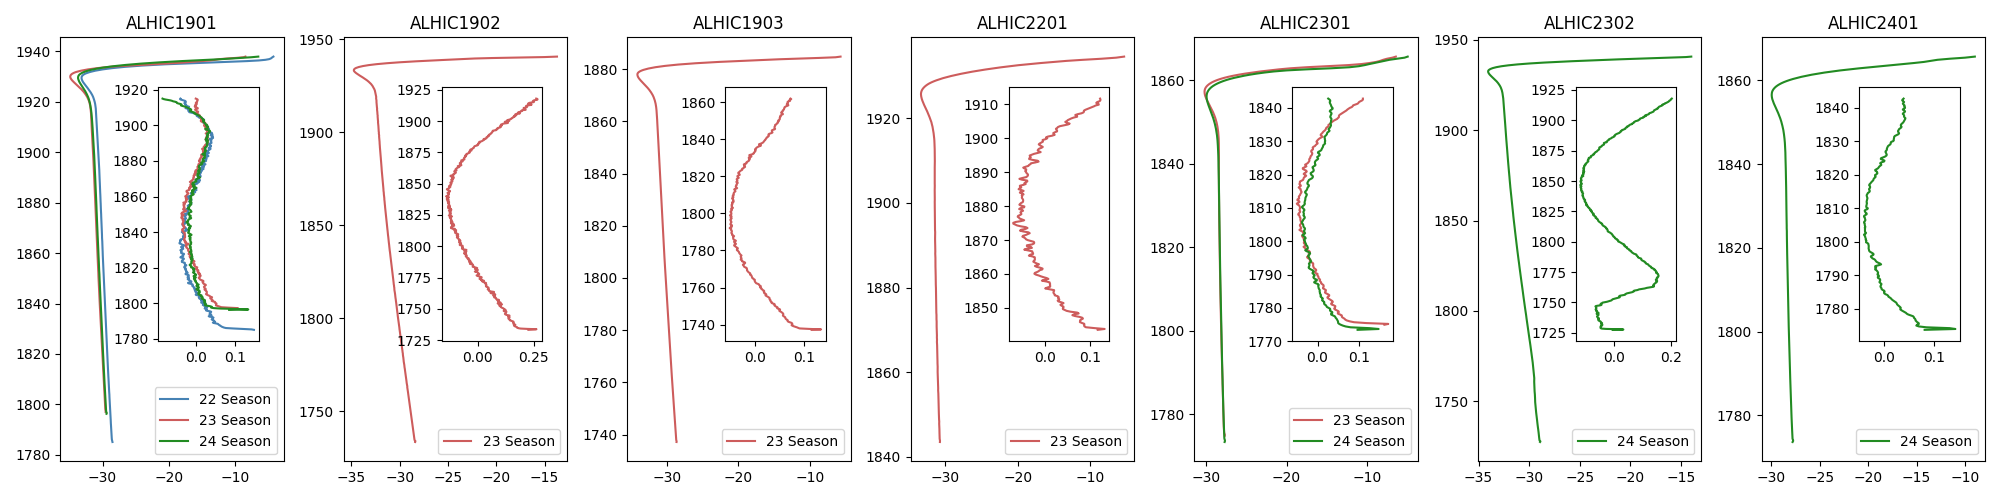

In [5]:
avg_temps = pd.read_pickle('../Borehole_Temps/avg_temps.pkl')
residual_temps = pd.read_pickle('../Borehole_Temps/residual_temps.pkl')

boreholes = ['ALHIC1901', 'ALHIC1902', 'ALHIC1903', 'ALHIC2201', 'ALHIC2301', 'ALHIC2302', 'ALHIC2401']

fig,axes = plt.subplots(1, len(boreholes), figsize=(20, 5))

insets = []
for ax in axes:
    axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .25, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
    insets.append(axinses)


for i in avg_temps:
    for borehole, ax, axins in zip(boreholes, axes, insets):

        if i.startswith(borehole):
            if i[-2:] == '22':
                color = 'steelblue'
            elif i[-2:] == '23':
                color = 'indianred'
            elif i[-2:] == '24':
                color = 'forestgreen'
            ax.plot(avg_temps[i][2], avg_temps[i][0], label=i[-2:]+' Season',c=color)
            axins.plot(residual_temps[i][2], residual_temps[i][0], label=i[-2:]+' Season',color=color)
            ax.legend()

            ax.set_title(borehole)

plt.tight_layout()
# plt.savefig('Fig2_borehole_temps.png', dpi=300)

# 2.0 Create the mesh from extrusion

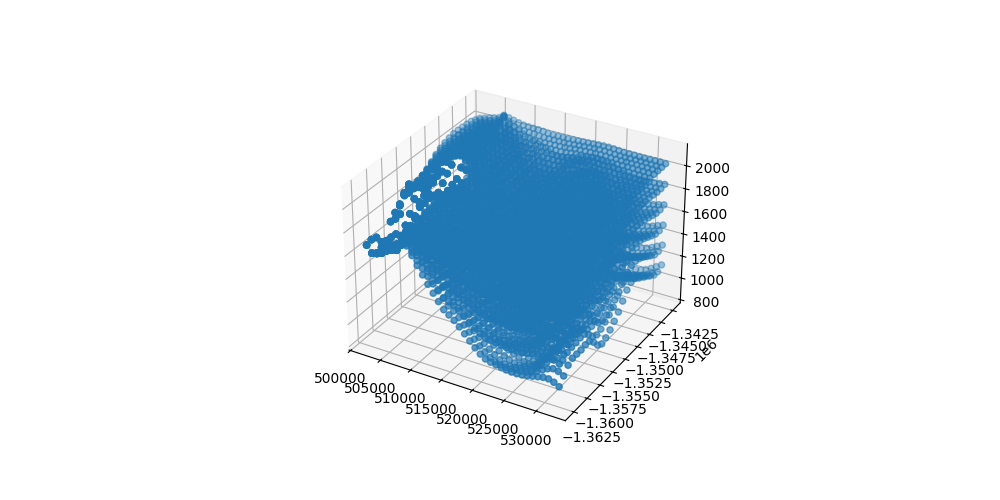

In [6]:
from firedrake import *
from firedrake.__future__ import interpolate

layers = 5 # number of layers in z direction of the extruded mesh
nx = width - 1
ny = height - 1

Lx = lons.max() # x extent, get this from the DEM
Ly = lats.max() # y extent, get this from the DEM

origin_x = lons.min() # origin (lower left corner) in x, get this from the DEM
origin_y = lats.min() # origin (lower left corner) in y, get this from the DEM

base_mesh = RectangleMesh(nx,ny, Lx, Ly, originX=origin_x, originY=origin_y)
# Make a height 1 mesh.
unit_extruded_mesh = ExtrudedMesh(base_mesh, layers=layers)

base_fs = FunctionSpace(base_mesh, "CG", 1)

x,y, = SpatialCoordinate(base_mesh)

# You could set this field any way you like.
## Bed and surface DEM resolution should be nx+1, ny+1 as to match the coordinates of the mesh.

# Now we transfer the bathymetry field into a depth-averaged field.
extruded_element = FiniteElement("R", "interval", 0)
extruded_space = FunctionSpace(unit_extruded_mesh,
                                TensorProductElement(base_fs.ufl_element(),
                                                    extruded_element))


from scipy.interpolate import griddata
## interpolate the DEMs to the mesh coordinates so it is given in the mesh coordinate order
points = np.array([xs,ys]).T # DEM pixel coordinates
xi = base_mesh.coordinates.dat.data_ro[:,:2] # Get the mesh coordinates from the base mesh
surf_interp = griddata(points, surf_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)
bed_interp = griddata(points, bed_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)

## Extrude the bed and surface
extruded_bed = Function(extruded_space)
extruded_bed.dat.data_wo[:] = bed_interp

extruded_surface = Function(extruded_space)
extruded_surface.dat.data_wo[:] = surf_interp

# Build a new coordinate field by change of coordinates.
x, y, z = SpatialCoordinate(unit_extruded_mesh)
new_coordinates = assemble(
    interpolate(
        as_vector([x, y, (1-z) * extruded_bed + z * extruded_surface]),
        unit_extruded_mesh.coordinates.function_space()
    )
)


# Finally build the mesh you are actually after.
mesh_src = Mesh(new_coordinates) # Mesh(new_coordinates, tolerance=50)
x_src, y_src, z_src = SpatialCoordinate(mesh_src)

## Plot using scatter since we can't plot Tensor product using triplot
ax = plt.figure(figsize=[10,5]).add_subplot(projection='3d')

ax.scatter(mesh_src.coordinates.dat.data_ro[:,0], mesh_src.coordinates.dat.data_ro[:,1], mesh_src.coordinates.dat.data_ro[:,2])

# 3. Create the FE model

## 3.1 Set up the flow (momentum) space

In [7]:
μ = Constant(5e15) #Ice


pressure_space = firedrake.FunctionSpace(mesh_src, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_src, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)
u, p = firedrake.split(flow)
v, q = firedrake.TestFunctions(flow.function_space())

τ = 2 * μ * ε(u)

g = as_vector((0, 0, grav))
f =  ρ * g

F_momentum = (inner(τ, ε(v)) - q * div(u) - p * div(v) - inner(f, v)) * dx

## 3.2 Boundary conditions for the flow

In [8]:
face_ids = ['top', 'bottom', 1, 2, 3, 4]

bc_stokes = []
for id in face_ids:
    if id == 'top': pass # Skip the top face for now (free flow)
    else:
        bc = firedrake.DirichletBC(Y.sub(0), as_vector((0, 0, 0)), id) # No flow on the boundaries
        bc_stokes.append(bc)

## 3.3 Do the Stokes solve

In [ ]:
basis = firedrake.VectorSpaceBasis(constant=True, comm=firedrake.COMM_WORLD)
nullspace = firedrake.MixedVectorSpaceBasis(Y, [Y.sub(0), basis])

stokes_problem = firedrake.NonlinearVariationalProblem(F_momentum, flow, bc_stokes)
parameters = {
    "nullspace": nullspace,
    "solver_parameters": {
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
}

stokes_solver = firedrake.NonlinearVariationalSolver(stokes_problem, **parameters)

stokes_solver.solve()

## 3.4 Plot the Stokes solution

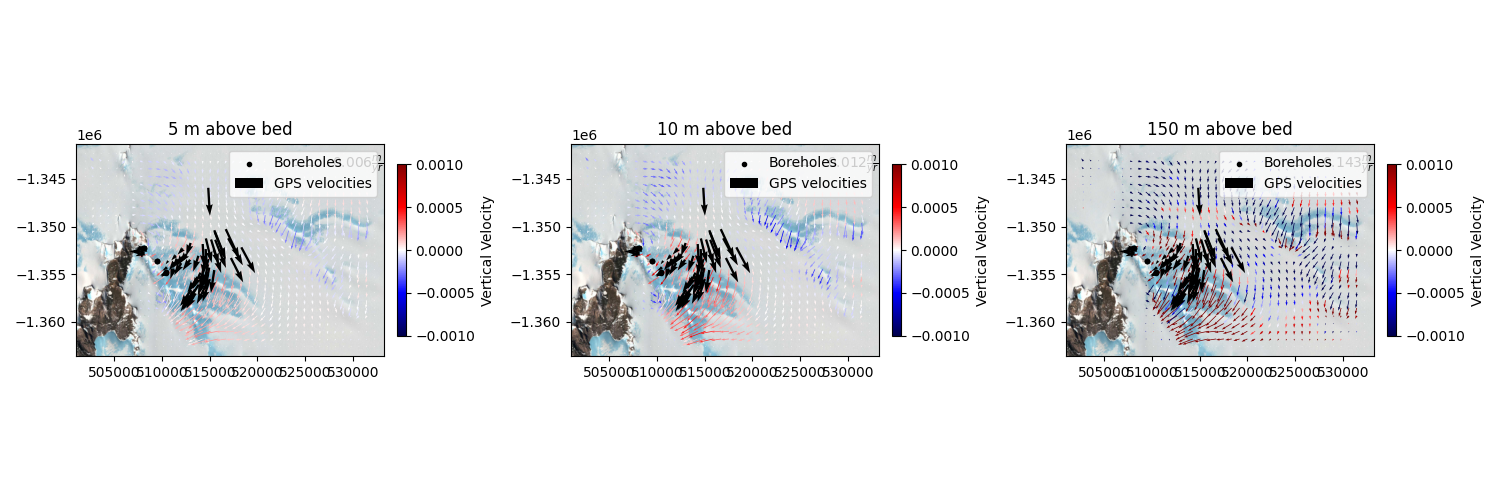

In [ ]:
cross_sections = [5,10,150]

fig, axes = plt.subplots(1,len(cross_sections),figsize=[15,5])

for n,m_above_bed in enumerate(cross_sections):
    vel_cross = []
    vel_cross_coords = []

    ### If the DEM includes some nonesense pixels in it, you need this block ##########
    # for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
    #     if 1998.99 < z_coord < 1999.01:
    #         continue
    #     else:
    #         vel_cross.append(y.at(x_coord, y_coord, z_coord+m_above_bed)[0])
    #         vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
    #####################################################################################

    ### If the DEM is perfectly rectangular, than you can do this block ####
    for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
        try:
            vel_cross.append(flow.at(x_coord, y_coord, z_coord+m_above_bed)[0])
            vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
        except:
            continue

    #########################################


    vel_cross = np.asarray(vel_cross)
    vel_cross_coords = np.asarray(vel_cross_coords)

    norm = mcolors.Normalize(vmin=-0.001, vmax=0.001)
    cmap = plt.cm.seismic
    colors = cmap(norm(vel_cross[:,2]*spy))

    show(image_data,ax=axes[n],transform=src1.transform)
    Q = axes[n].quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, scale = None, color=colors)

    axes[n].set_xlim([vel_cross_coords[:,0].min()-1000, vel_cross_coords[:,0].max()+1000])
    axes[n].set_ylim([vel_cross_coords[:,1].min()-1000, vel_cross_coords[:,1].max()+1000])

    axes[n].set_title(str(m_above_bed)+' m above bed')
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Needed only to satisfy colorbar creation
    cbar = plt.colorbar(sm, ax=axes[n], fraction=0.026, pad=0.04)
    cbar.set_label('Vertical Velocity')

    max_val = round(np.max(np.sqrt((vel_cross[:,0]*spy)**2+(vel_cross[:,1]*spy)**2)),3)
    axes[n].scatter(transformed_x,transformed_y, marker='.',color='black', label='Boreholes')
    max_val_str = str(max_val)
    qk = axes[n].quiverkey(Q, 0.8, 0.9, max_val, max_val_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')
    axes[n].quiver(gps_velocities['x'], gps_velocities['y'], 
                   gps_velocities['u'], gps_velocities['v'], 
                   scale = None, label='GPS velocities')
    axes[n].legend()

    #show(good_dem_filter,ax=axes[n],transform=src_good_dem.transform,cmap='gray', alpha=0.5)

plt.tight_layout()
# plt.savefig('3d_flow_cross_sections_long.png', dpi=300)

# 4. Interpolate this stokes solution onto a new mesh

## 4.0 Take the unit extruded mesh to map the flow field on (ie from 0 - 1)

- Here, I am just defining intermediate function spaces as defined by the "_coarse_norm" tag

In [51]:
pressure_space_coarse_norm = firedrake.FunctionSpace(unit_extruded_mesh, "CG", 1)
velocity_space_coarse_norm = firedrake.VectorFunctionSpace(unit_extruded_mesh, "CG", 3)
Y_coarse_norm = velocity_space_coarse_norm * pressure_space_coarse_norm
flow_coarse_norm = firedrake.Function(Y_coarse_norm)

## 4.0.1 Here, I am mapping the flow field we just calculated onto the coarse mesh that now is normed in elevation (ie from 0-1)

In [52]:
flow_coarse_norm.sub(0).dat.data[:] = flow.sub(0).dat.data_ro
flow_coarse_norm.sub(1).dat.data[:] = flow.sub(1).dat.data_ro

## 4.1 Here let's make the fine mesh in normed vertical coordinates

### 4.1.0 Load the fine mesh and plot

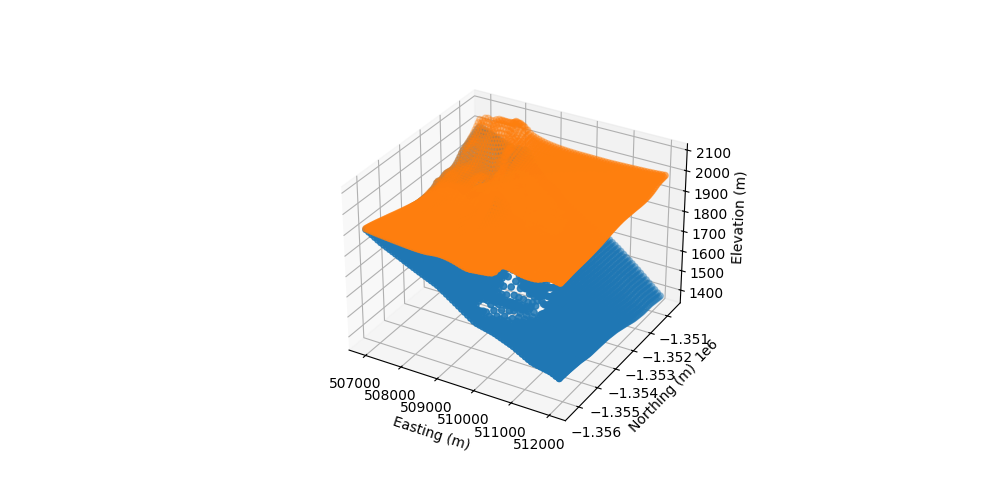

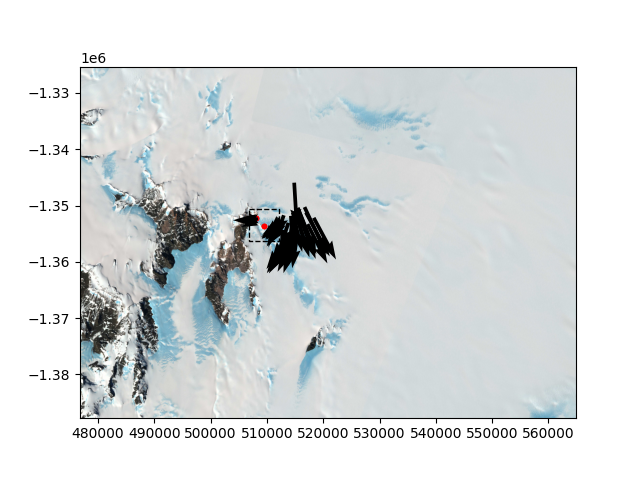

In [73]:
# Load tiff files of the DEMs

src_bed = src_bed_fine
src_surf = src_surf_fine

upscale_factor = 1/10


bed_DEM = src_bed.read(1,
                        out_shape=(
                            src_bed.count,
                            int(src_bed.height * upscale_factor),
                            int(src_bed.width * upscale_factor)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_bed_transform = src_bed.transform * src_bed.transform.scale(
    (src_bed.width / bed_DEM.shape[-1]),
    (src_bed.height / bed_DEM.shape[-2])
)


# src_surf = rasterio.open("../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif")

surf_DEM = src_surf.read(1,
                        out_shape=(
                            src_surf.count,
                            int(src_surf.height * upscale_factor),
                            int(src_surf.width * upscale_factor)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_surf_transform = src_surf.transform * src_surf.transform.scale(
    (src_surf.width / surf_DEM.shape[-1]),
    (src_surf.height / surf_DEM.shape[-2])
)

### Check if the bed DEMs is higher than the surface DEM (thickness is negative) ###


thickness = surf_DEM - bed_DEM
thickness[thickness > 0] = 0  # if positive, set to 0. This will mask the negative thickness values
zero_offset = copy.deepcopy(thickness)
zero_offset[zero_offset < 0 ] = -1 # this mask will lower the bed a further 1m in the areas where thickness is negative so the model doesn't crash on a zero.
bed_DEM = bed_DEM + thickness + zero_offset # add the negative values to the bed to push it lower to match the surface DEM



# surf_DEM[surf_DEM==0] = 2000 
# bed_DEM[bed_DEM==-1] = 1999
## Downsample the DEMs if desired
# downsample_factor = 20
# surf_DEM = surf_DEM[::downsample_factor, ::downsample_factor]
# bed_DEM = bed_DEM[::downsample_factor, ::downsample_factor]

height = surf_DEM.shape[0]
width = surf_DEM.shape[1]
cols, rows = np.meshgrid(np.arange(width), np.arange(height))
xs, ys = rasterio.transform.xy(src_surf_transform, rows, cols)
lons= np.array(xs)
lats = np.array(ys)

surf_elevs = surf_DEM.flatten()
bed_elevs = bed_DEM.flatten()

ax = plt.figure(figsize=[10,5]).add_subplot(projection='3d')

ax.scatter(lons, lats, bed_elevs)
ax.scatter(lons, lats, surf_elevs)

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_zlabel('Elevation (m)')

### Load boreholes
borehole_locations = pd.read_csv('../Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

### Load image data

with rasterio.open('../imagery/LIMA_virtual_Mosaic_15m.tif') as src1:
    image_data = src1.read()

fig, ax = plt.subplots()
ax.scatter(transformed_x,transformed_y, marker='.',c='red', label='Boreholes')
show(image_data,ax=ax,transform=src1.transform)

width_m = src_surf_transform[0] *surf_DEM.shape[1]
height_m = src_surf_transform[4] *surf_DEM.shape[0]

ax.add_patch(plt.Rectangle((src_surf_transform[2], src_surf_transform[5]),width_m,height_m,  ls='--', ec='black',fc='None'))

### Load the GPS velocities
gps_velocities = pd.read_csv('../GPS_velocities/24-25_velocities-good.csv')

GPS_points = []
for i in gps_velocities.iloc():
    GPS_points.append([i['x'], i['y']])
ax.quiver(gps_velocities['x'], gps_velocities['y'], 
                gps_velocities['u'], gps_velocities['v'], 
                scale = None, label='GPS velocities')

## 4.1.1 Make the fine mesh with a unit height (like we did for the coarse mesh)

In [74]:

from firedrake import *
from firedrake.__future__ import interpolate

layers = 5 # number of layers in z direction of the extruded mesh
nx = width - 1
ny = height - 1

Lx = lons.max() # x extent, get this from the DEM
Ly = lats.max() # y extent, get this from the DEM

origin_x = lons.min() # origin (lower left corner) in x, get this from the DEM
origin_y = lats.min() # origin (lower left corner) in y, get this from the DEM

base_mesh = RectangleMesh(nx,ny, Lx, Ly, originX=origin_x, originY=origin_y)
# Make a height 1 mesh.
unit_extruded_mesh = ExtrudedMesh(base_mesh, layers=layers)

xi = base_mesh.coordinates.dat.data_ro[:,:2] # Get the mesh coordinates from the base mesh

## 4.1.2 Now, we make the velocity / pressure function spaces for the fine mesh

In [75]:
pressure_space_fine_norm = firedrake.FunctionSpace(unit_extruded_mesh, "CG", 1)
velocity_space_fine_norm = firedrake.VectorFunctionSpace(unit_extruded_mesh, "CG", 3)
Y_fine_norm = velocity_space_fine_norm * pressure_space_fine_norm


## 4.1.3 Now, interpolate the coarse mesh flow field onto the fine mesh flow field

In [76]:
flow_fine_interp = assemble(interpolate(flow_coarse_norm, Function(Y_fine_norm)))

### 4.1.3.1 Plot the interpolated flow field

/usr/local/lib/python3.12/dist-packages/matplotlib/quiver.py:695: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
/usr/local/lib/python3.12/dist-packages/matplotlib/quiver.py:695: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


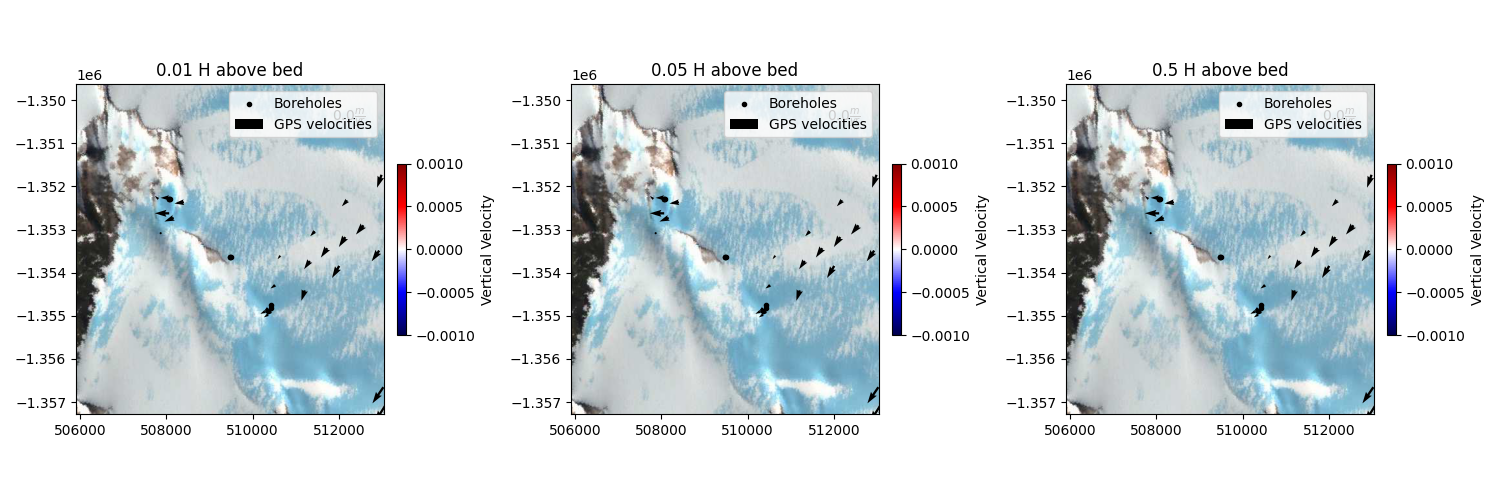

In [77]:
cross_sections = [.01,.05,.5]

fig, axes = plt.subplots(1,len(cross_sections),figsize=[15,5])

for n,m_above_bed in enumerate(cross_sections):
    vel_cross = []
    vel_cross_coords = []

    ### If the DEM includes some nonesense pixels in it, you need this block ##########
    # for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
    #     if 1998.99 < z_coord < 1999.01:
    #         continue
    #     else:
    #         vel_cross.append(y.at(x_coord, y_coord, z_coord+m_above_bed)[0])
    #         vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
    #####################################################################################

    ### If the DEM is perfectly rectangular, than you can do this block ####
    for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], np.array([0]*len(xi))):
        try:
            vel_cross.append(flow_fine_interp.at(x_coord, y_coord, z_coord+m_above_bed)[0])
            vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
        except:
            continue

    #########################################


    vel_cross = np.asarray(vel_cross)
    vel_cross_coords = np.asarray(vel_cross_coords)

    norm = mcolors.Normalize(vmin=-0.001, vmax=0.001)
    cmap = plt.cm.seismic
    colors = cmap(norm(vel_cross[:,2]*spy))

    show(image_data,ax=axes[n],transform=src1.transform)
    Q = axes[n].quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, scale = None, color=colors)

    axes[n].set_xlim([vel_cross_coords[:,0].min()-1000, vel_cross_coords[:,0].max()+1000])
    axes[n].set_ylim([vel_cross_coords[:,1].min()-1000, vel_cross_coords[:,1].max()+1000])

    axes[n].set_title(str(m_above_bed)+' H above bed')
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Needed only to satisfy colorbar creation
    cbar = plt.colorbar(sm, ax=axes[n], fraction=0.026, pad=0.04)
    cbar.set_label('Vertical Velocity')

    max_val = round(np.max(np.sqrt((vel_cross[:,0]*spy)**2+(vel_cross[:,1]*spy)**2)),3)
    axes[n].scatter(transformed_x,transformed_y, marker='.',color='black', label='Boreholes')
    max_val_str = str(max_val)
    qk = axes[n].quiverkey(Q, 0.8, 0.9, max_val, max_val_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')
    axes[n].quiver(gps_velocities['x'], gps_velocities['y'], 
                   gps_velocities['u'], gps_velocities['v'], 
                   scale = None, label='GPS velocities')
    axes[n].legend()

plt.tight_layout()

## 4.2 Now make the fine mesh

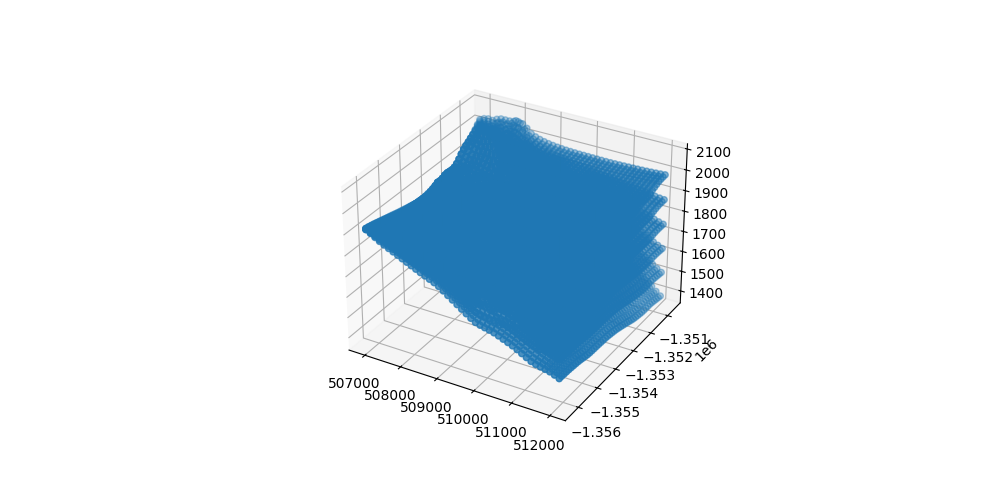

In [58]:
base_fs = FunctionSpace(base_mesh, "CG", 1)

x,y, = SpatialCoordinate(base_mesh)

# You could set this field any way you like.
## Bed and surface DEM resolution should be nx+1, ny+1 as to match the coordinates of the mesh.

# Now we transfer the bathymetry field into a depth-averaged field.
extruded_element = FiniteElement("R", "interval", 0)
extruded_space = FunctionSpace(unit_extruded_mesh,
                                TensorProductElement(base_fs.ufl_element(),
                                                    extruded_element))


from scipy.interpolate import griddata
## interpolate the DEMs to the mesh coordinates so it is given in the mesh coordinate order
points = np.array([xs,ys]).T # DEM pixel coordinates
xi = base_mesh.coordinates.dat.data_ro[:,:2] # Get the mesh coordinates from the base mesh
surf_interp = griddata(points, surf_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)
bed_interp = griddata(points, bed_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)

## Extrude the bed and surface
extruded_bed = Function(extruded_space)
extruded_bed.dat.data_wo[:] = bed_interp

extruded_surface = Function(extruded_space)
extruded_surface.dat.data_wo[:] = surf_interp

# Build a new coordinate field by change of coordinates.
x, y, z = SpatialCoordinate(unit_extruded_mesh)
new_coordinates = assemble(
    interpolate(
        as_vector([x, y, (1-z) * extruded_bed + z * extruded_surface]),
        unit_extruded_mesh.coordinates.function_space()
    )
)


# Finally build the mesh you are actually after.
mesh_fine = Mesh(new_coordinates) # Mesh(new_coordinates, tolerance=50)
x_fine, y_fine, z_fine = SpatialCoordinate(mesh_fine)

## Plot using scatter since we can't plot Tensor product using triplot
ax = plt.figure(figsize=[10,5]).add_subplot(projection='3d')

ax.scatter(mesh_fine.coordinates.dat.data_ro[:,0], mesh_fine.coordinates.dat.data_ro[:,1], mesh_fine.coordinates.dat.data_ro[:,2])

# 5. Set up the FE model

## 5.1 Make the flow function space

In [59]:
μ = Constant(5e15) #Ice


pressure_space = firedrake.FunctionSpace(mesh_fine, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_fine, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)
u, p = firedrake.split(flow)
v, q = firedrake.TestFunctions(flow.function_space())

τ = 2 * μ * ε(u)
g = as_vector((0, 0, grav))
f =  ρ * g

F_momentum = (inner(τ, ε(v)) - q * div(u) - p * div(v) - inner(f, v)) * dx

## 5.2 Do the boundary conditions. Here we will take the interpolated flow field

In [60]:
# Collapse velocity subspace for compatibility
V_trans = Y.sub(0).collapse()

# Interpolate old flow into that space
u_bc_func = Function(V_trans).interpolate(flow_fine_interp.sub(0))

In [61]:
face_ids = ['top', 'bottom', 1, 2, 3, 4]

bc_stokes = []
for id in face_ids:
    if id == 'top': pass # Skip the top face for now (free flow)
    else:
        bc = firedrake.DirichletBC(Y.sub(0), u_bc_func, id) # No flow on the boundaries
        bc_stokes.append(bc)

## 5.3 Now do the stokes solve on the fine mesh with the new boundary conditions from the coarse mesh

In [62]:
basis = firedrake.VectorSpaceBasis(constant=True, comm=firedrake.COMM_WORLD)
nullspace = firedrake.MixedVectorSpaceBasis(Y, [Y.sub(0), basis])

stokes_problem = firedrake.NonlinearVariationalProblem(F_momentum, flow, bc_stokes)
parameters = {
    "nullspace": nullspace,
    "solver_parameters": {
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
}

stokes_solver = firedrake.NonlinearVariationalSolver(stokes_problem, **parameters)

stokes_solver.solve()

### 5.3.1 Plot the solution to the Stokes solve on the fine mesh

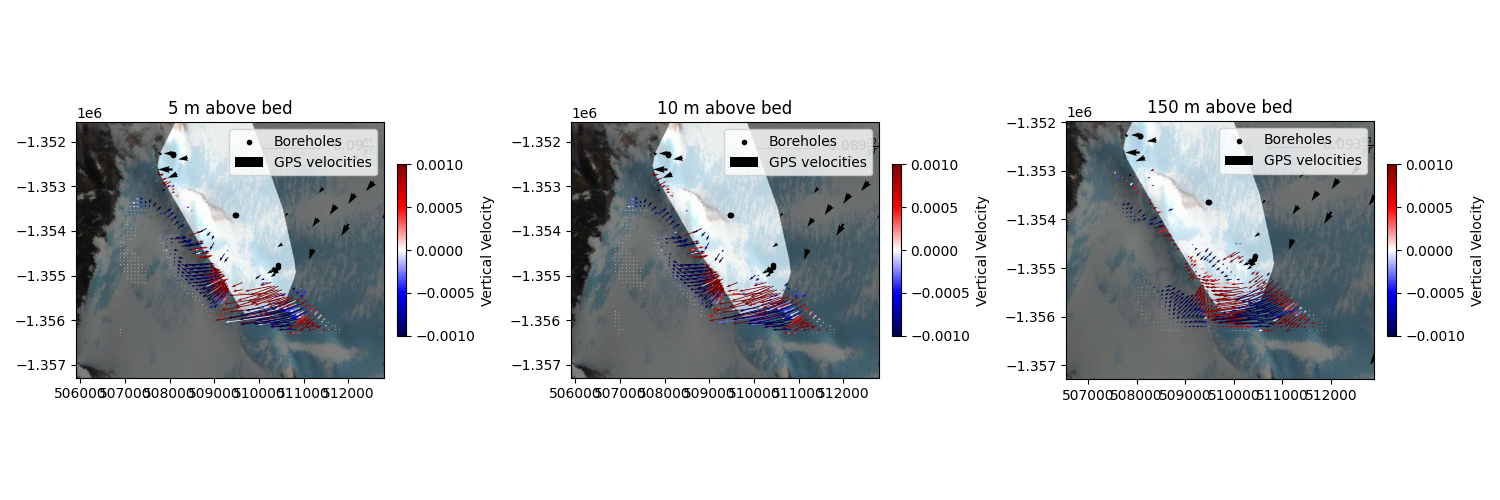

In [78]:
cross_sections = [5,10,150]

fig, axes = plt.subplots(1,len(cross_sections),figsize=[15,5])

for n,m_above_bed in enumerate(cross_sections):
    vel_cross = []
    vel_cross_coords = []

    ### If the DEM includes some nonesense pixels in it, you need this block ##########
    # for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
    #     if 1998.99 < z_coord < 1999.01:
    #         continue
    #     else:
    #         vel_cross.append(y.at(x_coord, y_coord, z_coord+m_above_bed)[0])
    #         vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
    #####################################################################################

    ### If the DEM is perfectly rectangular, than you can do this block ####
    for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
        try:
            vel_cross.append(flow.at(x_coord, y_coord, z_coord+m_above_bed)[0])
            vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
        except:
            continue

    #########################################


    vel_cross = np.asarray(vel_cross)
    vel_cross_coords = np.asarray(vel_cross_coords)

    norm = mcolors.Normalize(vmin=-0.001, vmax=0.001)
    cmap = plt.cm.seismic
    colors = cmap(norm(vel_cross[:,2]*spy))

    show(image_data,ax=axes[n],transform=src1.transform)
    Q = axes[n].quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, scale = None, color=colors)

    axes[n].set_xlim([vel_cross_coords[:,0].min()-1000, vel_cross_coords[:,0].max()+1000])
    axes[n].set_ylim([vel_cross_coords[:,1].min()-1000, vel_cross_coords[:,1].max()+1000])

    axes[n].set_title(str(m_above_bed)+' m above bed')
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Needed only to satisfy colorbar creation
    cbar = plt.colorbar(sm, ax=axes[n], fraction=0.026, pad=0.04)
    cbar.set_label('Vertical Velocity')

    max_val = round(np.max(np.sqrt((vel_cross[:,0]*spy)**2+(vel_cross[:,1]*spy)**2)),3)
    axes[n].scatter(transformed_x,transformed_y, marker='.',color='black', label='Boreholes')
    max_val_str = str(max_val)
    qk = axes[n].quiverkey(Q, 0.8, 0.9, max_val, max_val_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')
    axes[n].quiver(gps_velocities['x'], gps_velocities['y'], 
                   gps_velocities['u'], gps_velocities['v'], 
                   scale = None, label='GPS velocities')
    axes[n].legend()
    
    show(good_dem_filter,ax=axes[n],transform=src_good_dem.transform,cmap='gray', alpha=0.5)
plt.tight_layout()
# plt.savefig('3d_flow_cross_sections_long.png', dpi=300)

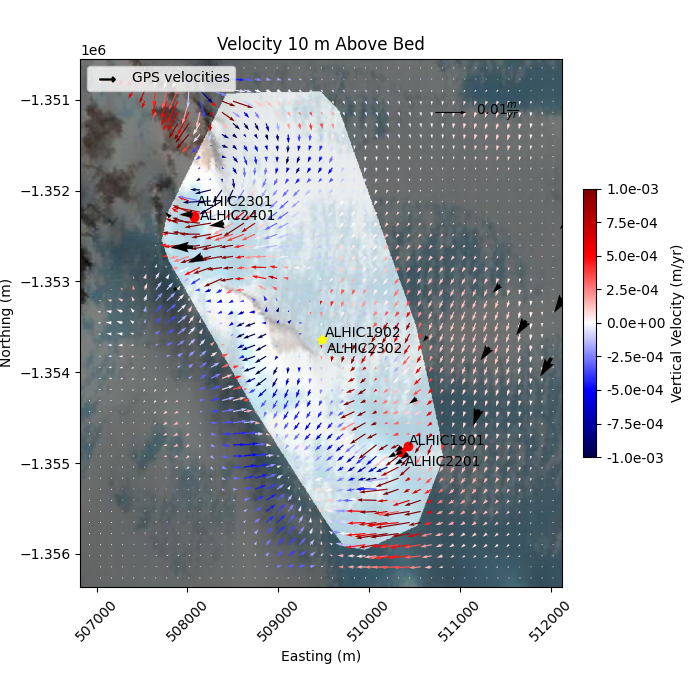

In [72]:


m_above_bed = 10

fig, axes = plt.subplots(figsize=[7,7])


vel_cross = []
vel_cross_coords = []

### If the DEM includes some nonesense pixels in it, you need this block ##########
# for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
#     if 1998.99 < z_coord < 1999.01:
#         continue
#     else:
#         vel_cross.append(y.at(x_coord, y_coord, z_coord+m_above_bed)[0])
#         vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
#####################################################################################

### If the DEM is perfectly rectangular, than you can do this block ####
for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
    try:
        vel_cross.append(flow.at(x_coord, y_coord, z_coord+m_above_bed)[0])
        vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
    except:
        vel_cross.append([np.nan, np.nan, np.nan])
        vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
        continue

#########################################


vel_cross = np.asarray(vel_cross)
vel_cross_coords = np.asarray(vel_cross_coords)

norm = mcolors.Normalize(vmin=-0.001, vmax=0.001)
cmap = plt.cm.seismic
colors = cmap(norm(vel_cross[:,2]*spy))


show(image_data,ax=axes,transform=src1.transform)




Q = axes.quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, 
                angles='xy', scale_units='xy', scale=None, color=colors)

axes.set_xlim([vel_cross_coords[:,0].min()-100, vel_cross_coords[:,0].max()+100])
axes.set_ylim([vel_cross_coords[:,1].min()-100, vel_cross_coords[:,1].max()+100])

axes.set_title("Velocity "+str(m_above_bed)+' m Above Bed')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed only to satisfy colorbar creation
cbar = plt.colorbar(sm, ax=axes, fraction=0.026, pad=0.04)
cbar.set_label('Vertical Velocity (m/yr)')

import matplotlib.ticker as ticker
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))

quiverkey_scale = 0.01
quiverkey_scale_str = str(quiverkey_scale)

## Plotting and annotating boreholes ##

axes.scatter(transformed_x[0],transformed_y[0], marker='o',color='red')
axes.annotate(borehole_locations.iloc()[0]['Core'], (transformed_x[0]+20,transformed_y[0]+20))

axes.scatter(transformed_x[1],transformed_y[1], marker='*',color='yellow')
axes.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+20,transformed_y[1]+20))

axes.scatter(transformed_x[2],transformed_y[2], marker='o',color='red')
axes.annotate(borehole_locations.iloc()[2]['Core'], (transformed_x[2]+20,transformed_y[2]+20))

axes.scatter(transformed_x[3],transformed_y[3], marker='o',color='red')
axes.annotate(borehole_locations.iloc()[3]['Core'], (transformed_x[3]+40,transformed_y[3]-150))

axes.scatter(transformed_x[4],transformed_y[4], marker='o',color='red')
axes.annotate(borehole_locations.iloc()[4]['Core'], (transformed_x[4]+40,transformed_y[4]+120))

axes.scatter(transformed_x[5],transformed_y[5], marker='*',color='yellow')
axes.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]+60,transformed_y[5]-150))

axes.scatter(transformed_x[6],transformed_y[6], marker='o',color='red')
axes.annotate(borehole_locations.iloc()[6]['Core'], (transformed_x[6]+60,transformed_y[6]-50))


qk = axes.quiverkey(Q, 0.8, 0.9, quiverkey_scale, quiverkey_scale_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')

axes.quiver(gps_velocities['x'], gps_velocities['y'], 
                gps_velocities['u'], gps_velocities['v'], 
                angles='xy', scale_units='xy', scale=None)

axes.scatter([], [], marker=r'$\longrightarrow$', color="black", s=120, label="GPS velocities")
axes.legend(loc='upper left')

# axes.set_ylim([-1.3555e6,-1.351e6])
# axes.set_xlim([507500,512000])
axes.set_xlabel('Easting (m)')
axes.set_ylabel('Northing (m)')

axes.xaxis.set_tick_params(rotation=45)
show(good_dem_filter,ax=axes,transform=src_good_dem.transform,cmap='gray', alpha=0.5)


plt.tight_layout()

# plt.savefig('embedded_model_transparent_10m.png', dpi=300, transparent=True)
# plt.savefig('embedded_model_white_10m.png', dpi=300, transparent=False)

TO DO: Add stipling to this to the areas that we don't trust

## 5.4 Save the velocity cross sections into a tiff so we can use it for other things

In [41]:
m_above_bed = 10


vel_cross = []
vel_cross_coords = []

for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
    try:
        vel_cross.append(flow.at(x_coord, y_coord, z_coord+m_above_bed)[0])
        vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
    except:
        vel_cross.append([np.nan, np.nan, np.nan])
        vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
        continue

#########################################


vel_cross = np.asarray(vel_cross)
vel_cross_coords = np.asarray(vel_cross_coords)

speed_in_m_per_yr = np.sqrt((vel_cross[:,0]*spy)**2+(vel_cross[:,1]*spy)**2+(vel_cross[:,2]*spy)**2)

## 5.4.1 Get the speed values into the shape of DEM relevant coordinates

In [42]:
xmin, ymin = xi.min(axis=0)
xmax, ymax = xi.max(axis=0)
nx, ny = bed_DEM.shape  # resolution

x_dem_coords = np.linspace(xmin, xmax, nx)
y_dem_coords = np.linspace(ymin, ymax, ny)
XS, YS = np.meshgrid(x_dem_coords, y_dem_coords, indexing='xy')

grid_values = griddata(xi, speed_in_m_per_yr, (XS, YS), method='nearest')  # 'linear' also possible


## 5.4.2 Save speed values to a Tiff

In [43]:
### This creates a new file for the bed map so we can do the proper bed elevation grabbing.

# Register GDAL format drivers and configuration options with a
# context manager.
with rasterio.Env():

    # Write an array as a raster band to a new 8-bit file. For
    # the new file's profile, we start with the profile of the source
    profile = src_bed.profile

    # And then change the band count to 1, set the
    # dtype to uint8, and specify LZW compression.
    profile.update(
        dtype=rasterio.float32,
        count=1,
        transform=src_bed_transform,
        nodata=np.nan,
        height=bed_DEM.shape[0],
        width=bed_DEM.shape[1]
        )

    with rasterio.open('../Processing_notebooks/speeds_tif_files/speed_'+str(m_above_bed)+'m.tif', 'w', **profile) as dst:
        dst.write(grid_values[::-1, :].astype(rasterio.float32), 1)

## 5.4.3 Load the Speed TIFF

<Axes: >

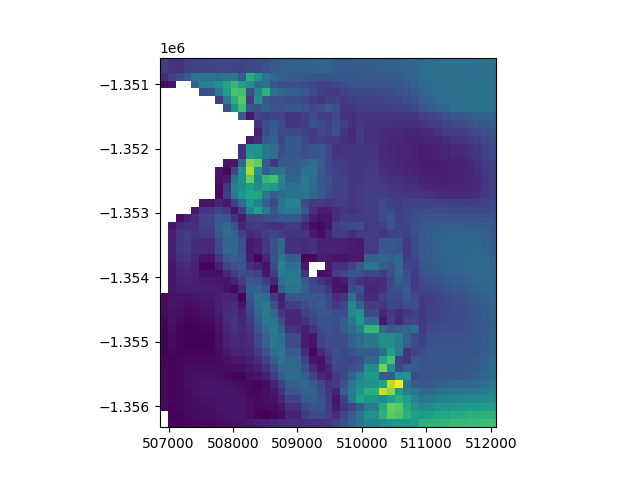

In [44]:
speed_2d = rasterio.open('../Processing_notebooks/speeds_tif_files/speed_'+str(m_above_bed)+'m.tif')


fig,ax = plt.subplots()
show(speed_2d, ax=ax, transform=speed_2d)

# 6. What is the relationship of flow speed and ice core age

## 6.0 Sample the speed map we made above

In [45]:
core_age = []
speed = []
core_names = []


for x_bore,y_bore,age, core_name in zip(transformed_x, transformed_y, borehole_locations['oldest ice'], borehole_locations['Core']):
    sampled_speed = [v[0] for v in speed_2d.sample([(x_bore, y_bore)])]

    speed.append(float(sampled_speed[0]))
    core_age.append(float(age/1e6))
    core_names.append(core_name)

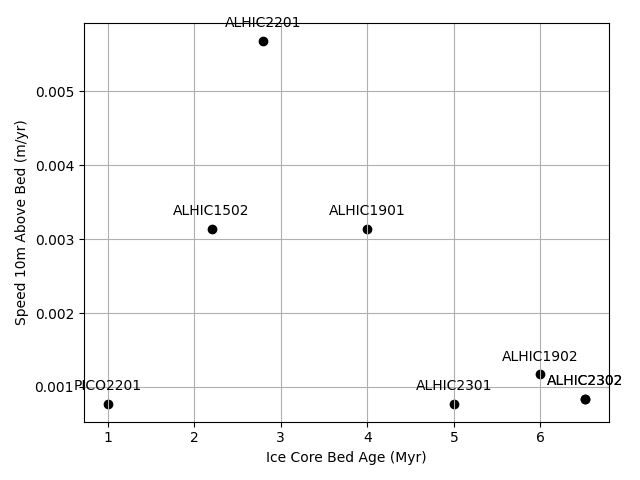

In [46]:
fig, ax = plt.subplots()

ax.scatter(core_age, speed, marker='o', c='black')

# ax.set_yscale('log')
# ax.set_xscale('log')

ax.set_ylabel('Speed '+str(m_above_bed)+'m Above Bed (m/yr)')
ax.set_xlabel('Ice Core Bed Age (Myr)')

for txt, x_fig_loc, y_fig_loc in zip(core_names, core_age, speed):
    ax.annotate(txt, (x_fig_loc, y_fig_loc), textcoords="offset points", xytext=(0,10), ha='center')

ax.grid()

# plt.savefig('speed_'+str(m_above_bed)+'m_vs_age_white.png', dpi=300, transparent=False, bbox_inches='tight')
# plt.savefig('speed_'+str(m_above_bed)+'m_vs_age_transparent.png', dpi=300, transparent=True, bbox_inches='tight')


plt.tight_layout()
plt.show()

# 7. Include temperature into this now

## 7.1 Make the temperature functions spaces and such

In [47]:
from ufl import Measure
dx = ufl.Measure("dx", domain=mesh_fine)

V = firedrake.FunctionSpace(mesh_fine, "CG", 1)
# V = firedrake.FunctionSpace(mesh, extruded_element)

T = firedrake.Function(V)
ϕ = firedrake.TestFunction(V)

geo_flux = 0.05 # W/m^2 
k = Constant(2.22)  # W / m C

geothermal_flux = -geo_flux*ϕ  * ds_b
F_diffusion = k*inner(grad(T), grad(ϕ)) * dx
F_advection = - ρ * c * T * inner(u, grad(ϕ)) * dx

F = F_diffusion + F_advection + geothermal_flux

## 7.2 Define the boundary condition

In [48]:
T_mean = -33 #average temp (C)

temperature_expr = T_mean - (z_fine - 2000)*.01

surface_temp_bc = firedrake.DirichletBC(V, temperature_expr, 'top')

## 7.3 Now solve for temperature

In [49]:
firedrake.solve(F == 0, T, [surface_temp_bc])

## 7.4 Plot the temperatures at the boreholes

### 7.4.1 Get the z values at the boreholes

In [50]:
z_vals = mesh_fine.coordinates.dat.data_ro[:,2]
depth_values = np.arange(z_vals.min(), z_vals.max(), 5)

temp_dict = {}

for x_bore, y_bore, name_bore in zip(transformed_x, transformed_y, borehole_locations['Core']):
    temp_coords = []
    temp_vals = []
    for z_bore in depth_values:
        try:
            temp = T.at(x_bore, y_bore, z_bore)
            temp_coords.append([x_bore, y_bore, z_bore])
            temp_vals.append(temp)
        except:
            continue
    if len(temp_vals) > 0:
        temp_dict[name_bore] = [np.array(temp_vals), np.array(temp_coords)]

### 7.4.2 Now plot

/tmp/ipykernel_96675/3869819974.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,axes = plt.subplots(1, len(temp_dict), figsize=[20,5])
/tmp/ipykernel_96675/3869819974.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


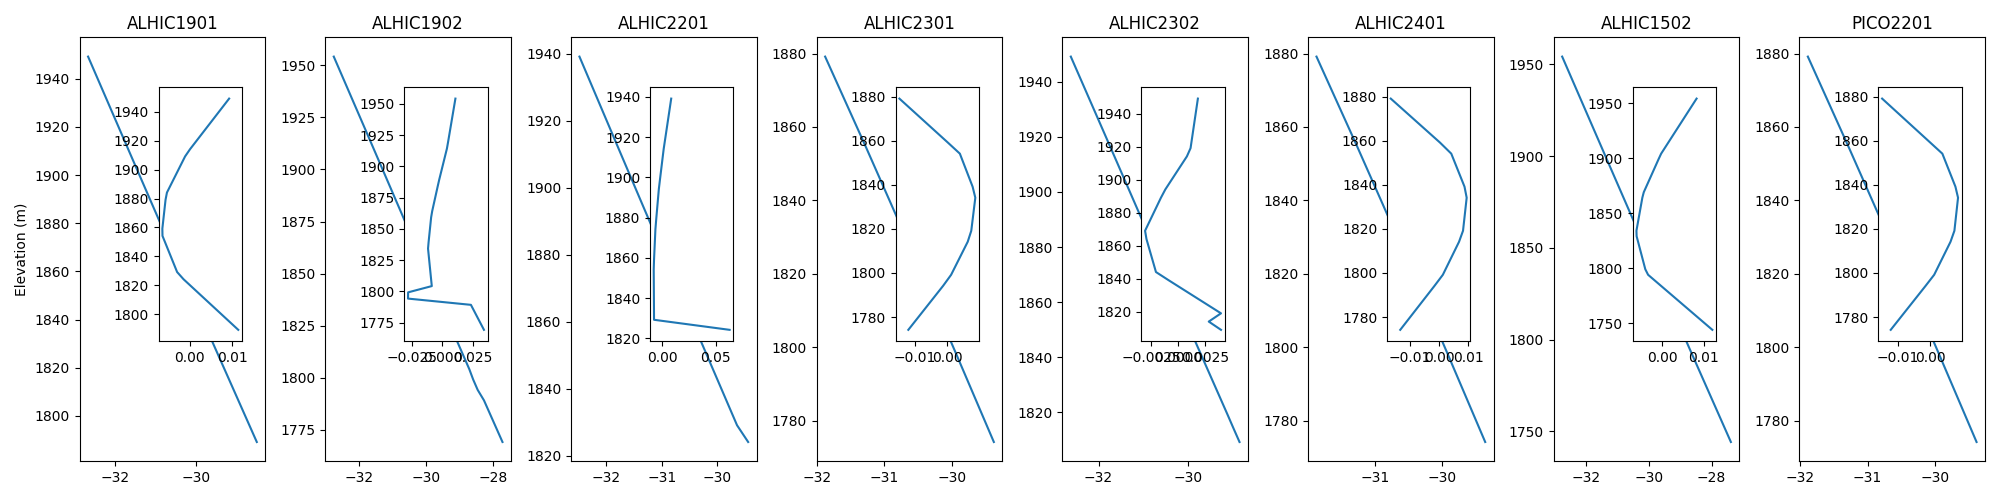

In [51]:
fig,axes = plt.subplots(1, len(temp_dict), figsize=[20,5])

for i, ax in zip(temp_dict, axes):
    ax.plot(temp_dict[i][0], temp_dict[i][1][:,2])
    ax.set_title(i)
    axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .25, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
    axinses.plot(scipy.signal.detrend(temp_dict[i][0]), temp_dict[i][1][:,2])
axes[0].set_ylabel('Elevation (m)')
plt.tight_layout()

/tmp/ipykernel_96675/4166293362.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


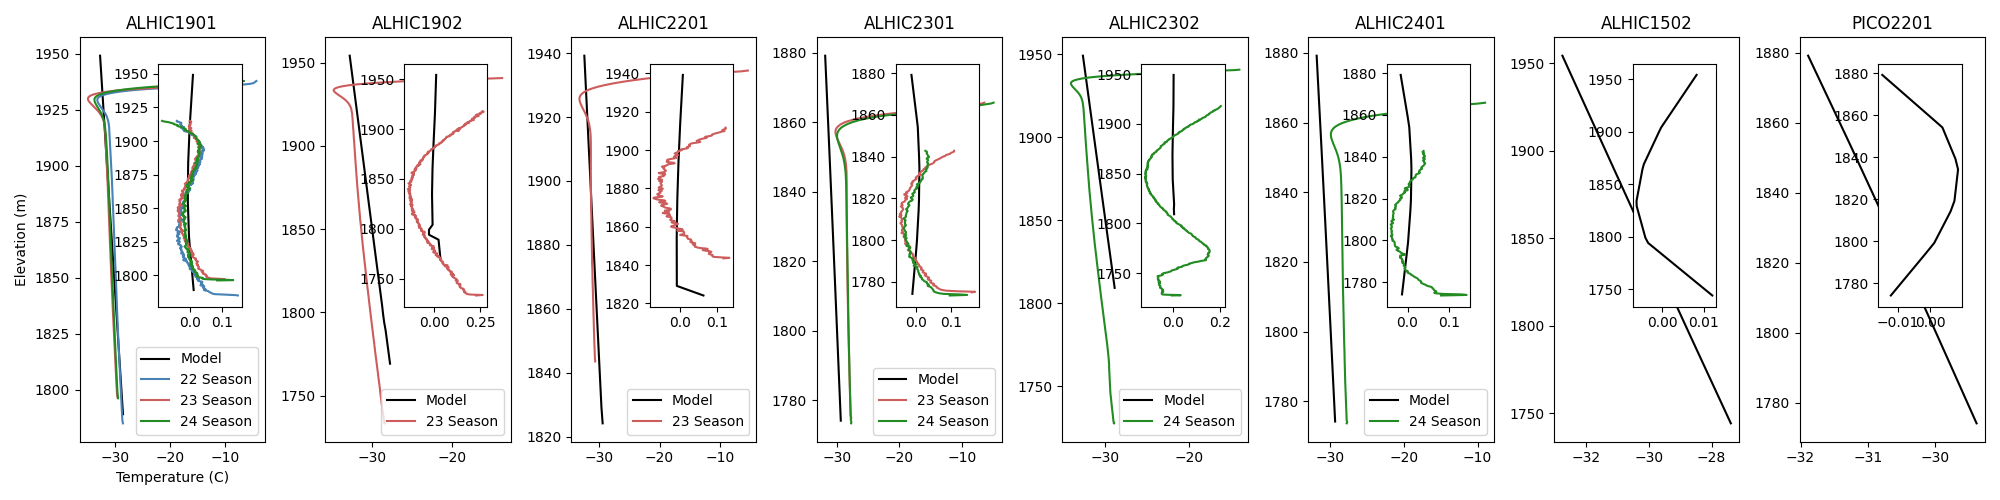

In [52]:
fig,axes = plt.subplots(1, len(temp_dict), figsize=[20,5])

for name, ax in zip(temp_dict, axes):
    ax.plot(temp_dict[name][0], temp_dict[name][1][:,2], c='black', label='Model')
    ax.set_title(i)

    axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
    axinses.plot(scipy.signal.detrend(temp_dict[name][0]), temp_dict[name][1][:,2], c='black')
    ax.set_title(name)
    for i in avg_temps:
        if i.startswith(name):
            if i[-2:] == '22':
                color = 'steelblue'
            elif i[-2:] == '23':
                color = 'indianred'
            elif i[-2:] == '24':
                color = 'forestgreen'
            ax.plot(avg_temps[i][2], avg_temps[i][0], label=i[-2:]+' Season',c=color)
            axinses.plot(residual_temps[i][2], residual_temps[i][0], label=i[-2:]+' Season',c=color)
            ax.legend(loc='lower right')

axes[0].set_ylabel('Elevation (m)')
axes[0].set_xlabel('Temperature (C)')
plt.tight_layout()

# plt.savefig('borehole_temps_vs_model_embedded_solve_transparent.png', dpi=300, transparent=True)
# plt.savefig('borehole_temps_vs_model_embedded_solve_white.png', dpi=300, transparent=False)

Put the figure above to have the 

# 7. Can we separate out the diffusion and advection components?

## 7.1 Set up the separate runs: one with only diffusion, and one including advection

In [53]:
from ufl import Measure
dx = ufl.Measure("dx", domain=mesh_fine)

V = firedrake.FunctionSpace(mesh_fine, "CG", 1)
# V = firedrake.FunctionSpace(mesh, extruded_element)

T_diff_only = firedrake.Function(V)
T_full = firedrake.Function(V)
ϕ = firedrake.TestFunction(V)

geo_flux = 0.05 # W/m^2 
k = Constant(2.22)  # W / m C

geothermal_flux = -geo_flux*ϕ  * ds_b
F_diffusion_diff_only = k*inner(grad(T_diff_only), grad(ϕ)) * dx
F_diffusion_full = k*inner(grad(T_full), grad(ϕ)) * dx
F_advection = - ρ * c * T_full * inner(u, grad(ϕ)) * dx

F_diffusion_and_geo = F_diffusion_diff_only + geothermal_flux
F_full = F_diffusion_full + F_advection + geothermal_flux

## 7.2 Boundary conditions

In [54]:
T_mean = Constant(-32.9999) #average temp (C)
T_Mean = -33 #average temp (C)

temperature_expr = T_mean - (z_fine - 2000)*.01

surface_temp_bc = firedrake.DirichletBC(V, temperature_expr, 'top')

## 7.3 Solve each field

In [55]:
firedrake.solve(F_diffusion_and_geo == 0, T_diff_only, [surface_temp_bc])
firedrake.solve(F_full == 0, T_full, [surface_temp_bc])

## 7.4 Plot temperature at each borehole

In [56]:
z_vals = mesh_fine.coordinates.dat.data_ro[:,2]
depth_values = np.arange(z_vals.min(), z_vals.max(), 5)

temp_dict = {}

for x_bore, y_bore, name_bore in zip(transformed_x, transformed_y, borehole_locations['Core']):
    temp_coords = []
    temp_vals_diff = []
    temp_vals_full = []
    for z_bore in depth_values:
        try:
            temp_diff_only = T_diff_only.at(x_bore, y_bore, z_bore)
            temp_full = T_full.at(x_bore, y_bore, z_bore)
            temp_coords.append([x_bore, y_bore, z_bore])
            temp_vals_diff.append(temp_diff_only)
            temp_vals_full.append(temp_full)
        except:
            continue
    if len(temp_vals_diff) > 0:
        temp_dict[name_bore] = [np.array(temp_vals_diff), np.array(temp_vals_full), np.array(temp_coords)]


## 7.5 Subtracting the diffusion only from the full to get advection contribution

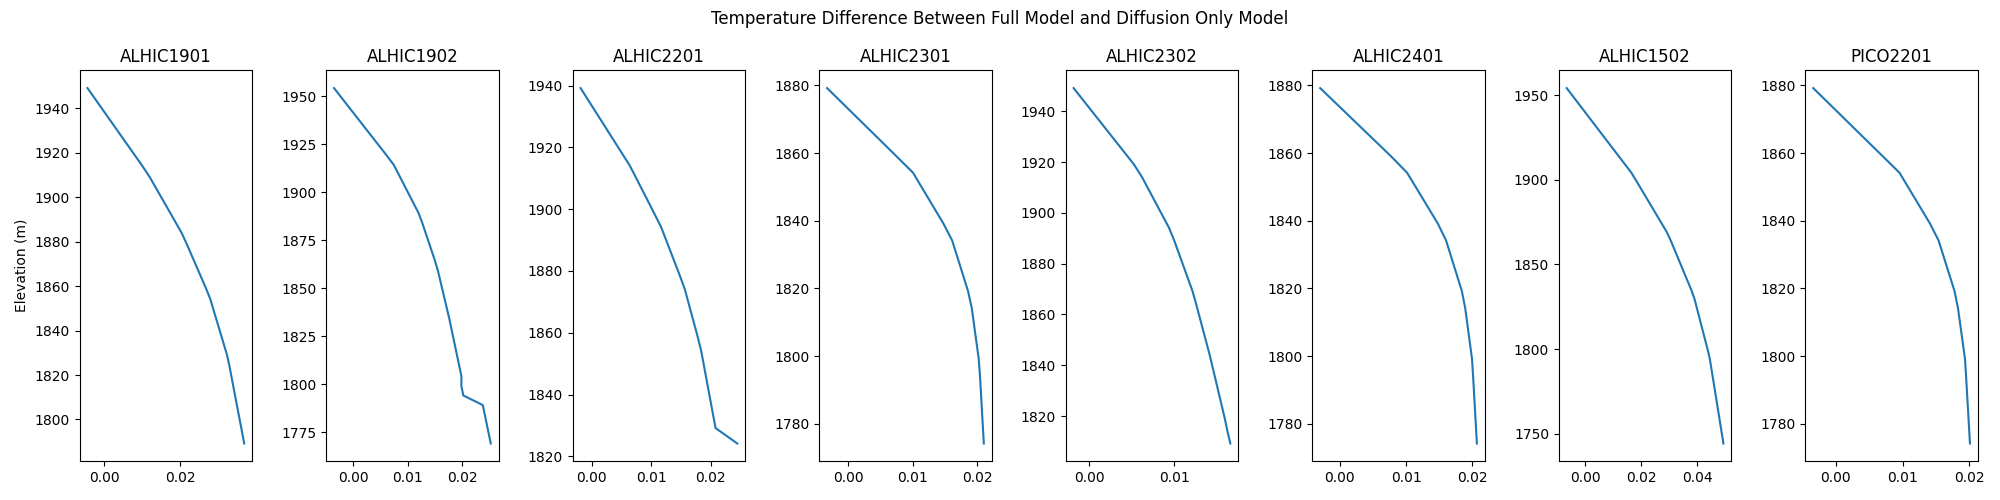

In [57]:
fig,axes = plt.subplots(1, len(temp_dict), figsize=[20,5])

for i, ax in zip(temp_dict, axes):
    ax.plot(temp_dict[i][1] - temp_dict[i][0], temp_dict[i][2][:,2], label = 'Diffusion Contribution')
    # ax.plot(temp_dict[i][1], temp_dict[i][2][:,2], label = 'Advection and Diffusion Only')
    ax.set_title(i)
    # axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .25, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
    # axinses.plot(scipy.signal.detrend(temp_dict[i][0]), temp_dict[i][2][:,2])
    # axinses.plot(scipy.signal.detrend(temp_dict[i][1]), temp_dict[i][2][:,2])
axes[0].set_ylabel('Elevation (m)')

fig.suptitle('Temperature Difference Between Full Model and Diffusion Only Model')
plt.tight_layout()

# plt.savefig('advection_contribution_temperature.png', dpi=300, transparent=False)

### 7.5.1 Interpolate it onto a field

In [58]:
T_adv_field = Function(V).interpolate(T_full - T_diff_only)

### 7.5.2 Save the interpolate field into a cross-sectional field

In [59]:
T_adv_field_cross = []
T_adv_field_cross_coords = []
m_above_bed = 10
for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
    try:
        T_adv_field_cross.append(T_adv_field.at(x_coord, y_coord, z_coord+m_above_bed))
        T_adv_field_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
    except:
        T_adv_field_cross.append(np.nan)
        T_adv_field_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
        continue

T_adv_field_cross = np.asarray(T_adv_field_cross)
T_adv_field_cross_coords = np.asarray(T_adv_field_cross_coords)

In [60]:
xmin, ymin = xi.min(axis=0)
xmax, ymax = xi.max(axis=0)
nx, ny = bed_DEM.shape  # resolution

x_dem_coords = np.linspace(xmin, xmax, nx)
y_dem_coords = np.linspace(ymin, ymax, ny)
XS, YS = np.meshgrid(x_dem_coords, y_dem_coords, indexing='xy')

grid_values = griddata(xi, T_adv_field_cross, (XS, YS), method='nearest')  # 'linear' also possible

In [61]:
### This creates a new file for the bed map so we can do the proper bed elevation grabbing.

# Register GDAL format drivers and configuration options with a
# context manager.
with rasterio.Env():

    # Write an array as a raster band to a new 8-bit file. For
    # the new file's profile, we start with the profile of the source
    profile = src_bed.profile

    # And then change the band count to 1, set the
    # dtype to uint8, and specify LZW compression.
    profile.update(
        dtype=rasterio.float32,
        count=1,
        transform=src_bed_transform,
        nodata=np.nan,
        height=bed_DEM.shape[0],
        width=bed_DEM.shape[1]
        )

    with rasterio.open('../Processing_notebooks/testing_figures/temp_adv_'+str(m_above_bed)+'m.tif', 'w', **profile) as dst:
        dst.write(grid_values[::-1, :].astype(rasterio.float32), 1)

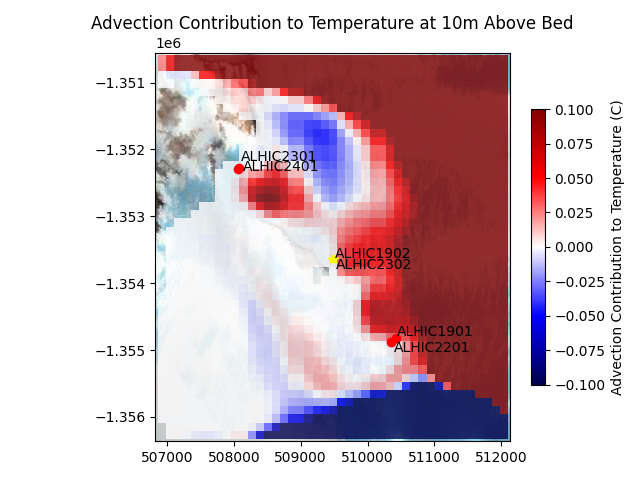

In [68]:
T_adv_field__map_view = rasterio.open('../Processing_notebooks/testing_figures/temp_adv_'+str(m_above_bed)+'m.tif')

vmin = -.1
vmax = .1

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.seismic
colors = cmap(norm(T_adv_field_cross))


fig,ax = plt.subplots()
show(image_data,ax=ax,transform=src1.transform)
show(T_adv_field__map_view, ax=ax, transform=T_adv_field__map_view, vmin=vmin, vmax=vmax, alpha=0.8, cmap=cmap)


sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed only to satisfy colorbar creation
cbar = plt.colorbar(sm, ax=ax, fraction=0.026, pad=0.04, label = 'Advection Contribution to Temperature (C)')


## Plotting and annotating boreholes ##

ax.scatter(transformed_x[0],transformed_y[0], marker='o',color='red')
ax.annotate(borehole_locations.iloc()[0]['Core'], (transformed_x[0]+20,transformed_y[0]+20))

ax.scatter(transformed_x[1],transformed_y[1], marker='*',color='yellow')
ax.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+20,transformed_y[1]+20))

ax.scatter(transformed_x[2],transformed_y[2], marker='o',color='red')
ax.annotate(borehole_locations.iloc()[2]['Core'], (transformed_x[2]+20,transformed_y[2]+20))

ax.scatter(transformed_x[3],transformed_y[3], marker='o',color='red')
ax.annotate(borehole_locations.iloc()[3]['Core'], (transformed_x[3]+40,transformed_y[3]-150))

ax.scatter(transformed_x[4],transformed_y[4], marker='o',color='red')
ax.annotate(borehole_locations.iloc()[4]['Core'], (transformed_x[4]+40,transformed_y[4]+120))

ax.scatter(transformed_x[5],transformed_y[5], marker='*',color='yellow')
ax.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]+60,transformed_y[5]-150))

ax.scatter(transformed_x[6],transformed_y[6], marker='o',color='red')
ax.annotate(borehole_locations.iloc()[6]['Core'], (transformed_x[6]+60,transformed_y[6]-50))

ax.set_title('Advection Contribution to Temperature at '+str(m_above_bed)+'m Above Bed')

ax.set_xlim([T_adv_field_cross_coords[:,0].min()-100, T_adv_field_cross_coords[:,0].max()+100])
ax.set_ylim([T_adv_field_cross_coords[:,1].min()-100, T_adv_field_cross_coords[:,1].max()+100])


plt.tight_layout()

plt.savefig('testing_figures/advection_contribution_map_view_'+str(m_above_bed)+'m.png', dpi=300, transparent=False)


- TO DO: stiple out the areas that we don't trust (show it on the map)
    - e.g. the areas that the DEM is bad (in the areas where we force it to be 1 m) or areas with weird ice thicknesses.


# 8. Adding a temperature (climate) signal

In [69]:
import irksome
from irksome import Dt

δx = mesh_fine.cell_sizes.dat.data_ro[:].min()
umax = flow.sub(0).dat.data_ro[:].max()
δt = Constant(spy/.1)


In [70]:
δT * np.sin(2 * π *freq* t / year + θ)

NameError: name 'δT' is not defined

<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_96675/3129181096.py:22: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("temperature (${}^\circ$C)")


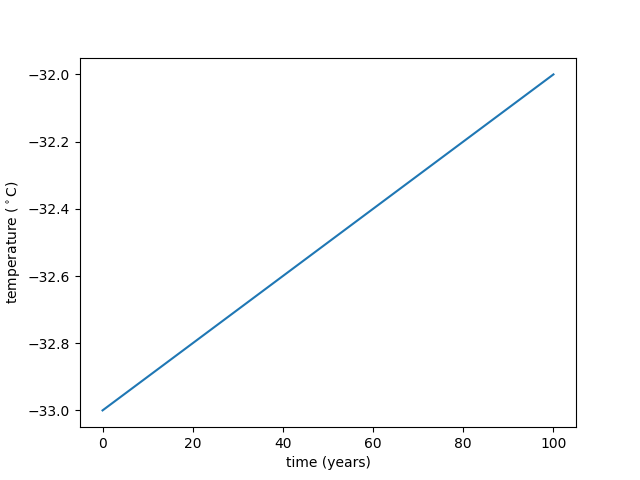

In [71]:
δT = 25.0
θ = 1 * π / 2
year = spy
years = 100
final_time = years * spy # years modeling * spy

freq = 1 # 1 for annual cycle
num_steps = int(final_time / float(δt))

# def surface_temperature(t):
#     return T_Mean + δT * np.sin(2 * π *freq* t / year + θ) + (t/final_time)*1

def surface_temperature(t):
    return T_Mean + (t/final_time)*1

ts = np.linspace(0.0, final_time, num_steps + 1)

surface_temps = surface_temperature(ts)

fig, ax = plt.subplots()
ax.set_xlabel("time (years)")
ax.set_ylabel("temperature (${}^\circ$C)")
ax.plot(ts / spy, surface_temps);

In [72]:
F = ρ * c * Dt(T_full) * ϕ * dx + F_diffusion_full + F_advection + geothermal_flux

In [73]:
method = irksome.BackwardEuler()
temperature_solver = irksome.TimeStepper(F, method, Constant(0.0), δt, T_full, bcs=surface_temp_bc)

In [74]:
import tqdm
final_time = years* spy 
num_steps = int(final_time / float(δt))
Ts = [T_full.copy(deepcopy=True)]
flows = [flow.copy(deepcopy=True)]

for step in tqdm.trange(num_steps):
    t = ts[step]
    T_mean.assign(surface_temperature(t))

    temperature_solver.advance()
    stokes_solver.solve()

    Ts.append(T_full.copy(deepcopy=True))
    flows.append(flow.copy(deepcopy=True))

100%|██████████| 10/10 [43:04<00:00, 258.45s/it]


## 8.1 Plot the temperature at each borehole at the end of the climate trend

In [75]:
z_vals = mesh_fine.coordinates.dat.data_ro[:,2]
depth_values = np.arange(z_vals.min(), z_vals.max(), 5)

temp_dict_climate = {}

for x_bore, y_bore, name_bore in zip(transformed_x, transformed_y, borehole_locations['Core']):
    temp_coords = []
    temp_vals = []
    for z_bore in depth_values:
        try:
            temp = Ts[-1].at(x_bore, y_bore, z_bore)
            temp_coords.append([x_bore, y_bore, z_bore])
            temp_vals.append(temp)
        except:
            continue
    if len(temp_vals) > 0:
        temp_dict_climate[name_bore] = [np.array(temp_vals), np.array(temp_coords)]

/tmp/ipykernel_96675/3784599842.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


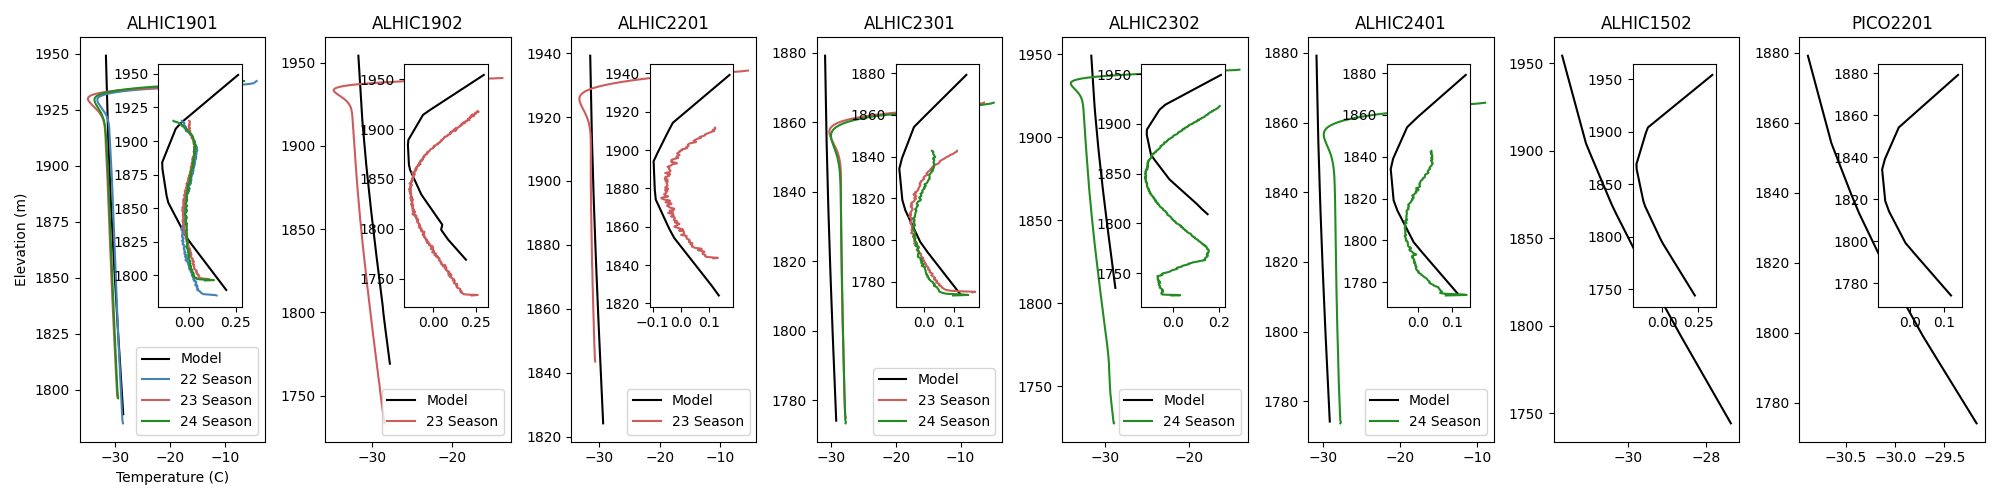

In [76]:
fig,axes = plt.subplots(1, len(temp_dict), figsize=[20,5])

for name, ax in zip(temp_dict_climate, axes):
    ax.plot(temp_dict_climate[name][0], temp_dict_climate[name][1][:,2], c='black', label='Model')
    ax.set_title(i)

    axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
    axinses.plot(scipy.signal.detrend(temp_dict_climate[name][0]), temp_dict_climate[name][1][:,2], c='black')
    ax.set_title(name)
    for i in avg_temps:
        if i.startswith(name):
            if i[-2:] == '22':
                color = 'steelblue'
            elif i[-2:] == '23':
                color = 'indianred'
            elif i[-2:] == '24':
                color = 'forestgreen'
            ax.plot(avg_temps[i][2], avg_temps[i][0], label=i[-2:]+' Season',c=color)
            axinses.plot(residual_temps[i][2], residual_temps[i][0], label=i[-2:]+' Season',c=color)
            ax.legend(loc='lower right')

axes[0].set_ylabel('Elevation (m)')
axes[0].set_xlabel('Temperature (C)')
plt.tight_layout()

plt.savefig('testing_figures/borehole_temps_climate_signal_transparent.png', dpi=300, transparent=True)
plt.savefig('testing_figures/borehole_temps_climate_signal_white.png', dpi=300, transparent=False)

in the above figure, set all the residual temperature plots to have the same x-axis

# 9. Now the updating of viscosity

In [ ]:
T_new,flow, stokes_solver = viscosity_updater_3d(x,z,ϕ,T,flow,u,V,[surface_temp_bc],mesh_fine)

21.42285194301196
0.01967845289263025
0.02372353457707773


# Notes from (9/30/25)

- Using the borehole temperature data: compare the shapes of residuals of the boreholes data to the model
    - In terms of borehole temperatures: we really only have data in the slow flow areas and it could be useful to get data in the fast flow area.
- Possible test: Subtract out the diffusion and geoflux contribution and only leave the advection piece. What does the spatial relationship of advection look like? Compare this to only the diffusion problem (no advection)
- Do the time dpendent problem (only in temperature)

# Notes from (10/14/25)

- Figures for PNAS

    - Fig 1: Flow model results (map of the velocity vectors)
    - Fig 2: Model temps with the borehole temperatures (maybe we can show the advection contribution at each of the boreholes here in some way?)
    - Fig 3: Ice core age vs flow speed map
    - Fig 4: A new ice schematic that counters the traditional Allan Hills model of ice flow. e.g we have downward flowing ice from the nunatak.

    - supporting info
        - Fig 1: overview map (DEMs/imagery/ice cores)

TO DO (nice to have): Try some analytical solutions to understand advection piece (from Cuffey and Patterson)

## Notes from Dan

- Put the fine mesh into normalized depths (from 0 (bed) - 1 (surface)) as well as the coarse mesh and then use that to map to one another